In [1]:
import illustris_python as il
import numpy as np
import sys,os,h5py,time
import readgadget
import MAS_library as MASL
import units_library as UL
import sorting_library as SL
import Pk_library as PKL
# import HI_library as HIL
import scipy.spatial as SS

# define constants here
rho_crit   = UL.units().rho_crit #h^2 Msun/Mpc^3
BOLTZMANN  = 1.38065e-16         #erg/K - NIST 2010
PROTONMASS = 1.67262178e-24      #gram  - NIST 2010




In [2]:
""" Illustris Simulation: Public Data Release.
util.py: Various helper functions. """

def partTypeNum(partType):
    """ Mapping between common names and numeric particle types. """
    if str(partType).isdigit():
        return int(partType)
        
    if str(partType).lower() in ['gas','cells']:
        return 0
    if str(partType).lower() in ['dm','darkmatter']:
        return 1
    if str(partType).lower() in ['dmlowres']:
        return 2 # only zoom simulations, not present in full periodic boxes
    if str(partType).lower() in ['tracer','tracers','tracermc','trmc']:
        return 3
    if str(partType).lower() in ['star','stars','stellar']:
        return 4 # only those with GFM_StellarFormationTime>0
    if str(partType).lower() in ['wind']:
        return 4 # only those with GFM_StellarFormationTime<0
    if str(partType).lower() in ['bh','bhs','blackhole','blackholes']:
        return 5
    
    raise Exception("Unknown particle type name.")

import numpy as np
import h5py
import six

def snapPath(basePath, snapNum, chunkNum=0):
    """ Return absolute path to a snapshot HDF5 file (modify as needed). """
    # snapPath = basePath + '/snapdir_' + str(snapNum).zfill(3) + '/'
    filePath = basePath + 'snap_' + str(snapNum).zfill(3)
    filePath += '.' + str(chunkNum) + '.hdf5'
    return filePath


def getNumPart(header):
    """ Calculate number of particles of all types given a snapshot header. """
    nTypes = 6

    nPart = np.zeros(nTypes, dtype=np.int64)
    for j in range(nTypes):
        nPart[j] = header['NumPart_Total'][j] | (header['NumPart_Total_HighWord'][j] << 32)

    return nPart


def loadSubset(basePath, snapNum, partType, fields=None, subset=None, mdi=None, sq=True, float32=False):
    """ Load a subset of fields for all particles/cells of a given partType.
        If offset and length specified, load only that subset of the partType.
        If mdi is specified, must be a list of integers of the same length as fields,
        giving for each field the multi-dimensional index (on the second dimension) to load.
          For example, fields=['Coordinates', 'Masses'] and mdi=[1, None] returns a 1D array
          of y-Coordinates only, together with Masses.
        If sq is True, return a numpy array instead of a dict if len(fields)==1.
        If float32 is True, load any float64 datatype arrays directly as float32 (save memory). """
    result = {}

    ptNum = partTypeNum(partType)
    gName = "PartType" + str(ptNum)

    # make sure fields is not a single element
    if isinstance(fields, six.string_types):
        fields = [fields]

    # load header from first chunk
    with h5py.File(snapPath(basePath, snapNum), 'r') as f:

        header = dict(f['Header'].attrs.items())
        nPart = getNumPart(header)

        # decide global read size, starting file chunk, and starting file chunk offset
        if subset:
            offsetsThisType = subset['offsetType'][ptNum] - subset['snapOffsets'][ptNum, :]

            fileNum = np.max(np.where(offsetsThisType >= 0))
            fileOff = offsetsThisType[fileNum]
            numToRead = subset['lenType'][ptNum]
        else:
            fileNum = 0
            fileOff = 0
            numToRead = nPart[ptNum]

        result['count'] = numToRead

        if not numToRead:
            # print('warning: no particles of requested type, empty return.')
            return result

        # find a chunk with this particle type
        i = 1
        while gName not in f:
            f = h5py.File(snapPath(basePath, snapNum, i), 'r')
            i += 1

        # if fields not specified, load everything
        if not fields:
            fields = list(f[gName].keys())

        for i, field in enumerate(fields):
            # verify existence
            if field not in f[gName].keys():
                raise Exception("Particle type ["+str(ptNum)+"] does not have field ["+field+"]")

            # replace local length with global
            shape = list(f[gName][field].shape)
            shape[0] = numToRead

            # multi-dimensional index slice load
            if mdi is not None and mdi[i] is not None:
                if len(shape) != 2:
                    raise Exception("Read error: mdi requested on non-2D field ["+field+"]")
                shape = [shape[0]]

            # allocate within return dict
            dtype = f[gName][field].dtype
            if dtype == np.float64 and float32: dtype = np.float32
            result[field] = np.zeros(shape, dtype=dtype)

    # loop over chunks
    wOffset = 0
    origNumToRead = numToRead

    while numToRead:
        f = h5py.File(snapPath(basePath, snapNum, fileNum), 'r')

        # no particles of requested type in this file chunk?
        if gName not in f:
            f.close()
            fileNum += 1
            fileOff  = 0
            continue

        # set local read length for this file chunk, truncate to be within the local size
        numTypeLocal = f['Header'].attrs['NumPart_ThisFile'][ptNum]

        numToReadLocal = numToRead

        if fileOff + numToReadLocal > numTypeLocal:
            numToReadLocal = numTypeLocal - fileOff

        #print('['+str(fileNum).rjust(3)+'] off='+str(fileOff)+' read ['+str(numToReadLocal)+\
        #      '] of ['+str(numTypeLocal)+'] remaining = '+str(numToRead-numToReadLocal))

        # loop over each requested field for this particle type
        for i, field in enumerate(fields):
            # read data local to the current file
            if mdi is None or mdi[i] is None:
                result[field][wOffset:wOffset+numToReadLocal] = f[gName][field][fileOff:fileOff+numToReadLocal]
            else:
                result[field][wOffset:wOffset+numToReadLocal] = f[gName][field][fileOff:fileOff+numToReadLocal, mdi[i]]

        wOffset   += numToReadLocal
        numToRead -= numToReadLocal
        fileNum   += 1
        fileOff    = 0  # start at beginning of all file chunks other than the first

        f.close()

    # verify we read the correct number
    if origNumToRead != wOffset:
        raise Exception("Read ["+str(wOffset)+"] particles, but was expecting ["+str(origNumToRead)+"]")

    # only a single field? then return the array instead of a single item dict
    if sq and len(fields) == 1:
        return result[fields[0]]

    return result


def getSnapOffsets(basePath, snapNum, id, type):
    """ Compute offsets within snapshot for a particular group/subgroup. """
    r = {}

    # old or new format
    if 'fof_subhalo' in gcPath(basePath, snapNum):
        # use separate 'offsets_nnn.hdf5' files
        with h5py.File(offsetPath(basePath, snapNum), 'r') as f:
            groupFileOffsets = f['FileOffsets/'+type][()]
            r['snapOffsets'] = np.transpose(f['FileOffsets/SnapByType'][()])  # consistency
    else:
        # load groupcat chunk offsets from header of first file
        with h5py.File(gcPath(basePath, snapNum), 'r') as f:
            groupFileOffsets = f['Header'].attrs['FileOffsets_'+type]
            r['snapOffsets'] = f['Header'].attrs['FileOffsets_Snap']

    # calculate target groups file chunk which contains this id
    groupFileOffsets = int(id) - groupFileOffsets
    fileNum = np.max(np.where(groupFileOffsets >= 0))
    groupOffset = groupFileOffsets[fileNum]

    # load the length (by type) of this group/subgroup from the group catalog
    with h5py.File(gcPath(basePath, snapNum, fileNum), 'r') as f:
        r['lenType'] = f[type][type+'LenType'][groupOffset, :]

    # old or new format: load the offset (by type) of this group/subgroup within the snapshot
    if 'fof_subhalo' in gcPath(basePath, snapNum):
        with h5py.File(offsetPath(basePath, snapNum), 'r') as f:
            r['offsetType'] = f[type+'/SnapByType'][id, :]
    else:
        with h5py.File(gcPath(basePath, snapNum, fileNum), 'r') as f:
            r['offsetType'] = f['Offsets'][type+'_SnapByType'][groupOffset, :]

    return r


    



In [3]:
ldir = '/work/hdd/bdne/spandey3/illustris_tng/L205n1250TNG/snapdir_099/'

pos_gas = np.array(loadSubset(ldir, 99, 0, fields='Coordinates')/1e3, dtype=np.float32)



In [6]:
eta_e = np.array(loadSubset(ldir, 99, 0, fields='ElectronAbundance'), dtype=np.float32)



In [8]:
eta_e


array([1.1605833, 1.1605699, 1.1605732, ..., 1.1575631, 1.1578813,
       1.15782  ], dtype=float32)

In [ ]:
X_H = np.array(loadSubset(ldir, 99, 0, fields='GFM_Metals'), dtype=np.float32)[:,0]




In [7]:
X_H[:,0]





array([0.75501925, 0.7550444 , 0.7550384 , ..., 0.76      , 0.7599928 ,
       0.76      ], dtype=float32)

In [3]:
ldir = '/work/hdd/bdne/spandey3/illustris_tng/L205n1250TNG/snapdir_099/'

pos_gas = np.array(loadSubset(ldir, 99, 0, fields='Coordinates')/1e3, dtype=np.float32)
df1 = np.array(loadSubset(ldir, 99, 1, fields='Coordinates')/1e3, dtype=np.float32)
df4 = np.array(loadSubset(ldir, 99, 4, fields='Coordinates')/1e3, dtype=np.float32)
df5 = np.array(loadSubset(ldir, 99, 5, fields='Coordinates')/1e3, dtype=np.float32)

pos_all = np.concatenate((pos_gas, df1, df4, df5), dtype=np.float32)


In [4]:
ji = 0
snapshot = ldir + 'snap_099.' + str(ji) + '.hdf5'
head     = readgadget.header(snapshot)
BoxSize  = head.boxsize/1e3  #Mpc/h  
Masses   = head.massarr * 1e10 #Masses of the particles in Msun/h                    

mass_gas = np.array(loadSubset(ldir, 99, 0, fields='Masses') * 1e10, dtype=np.float32)
# df1 = np.array(loadSubset(ldir, 99, 1, fields='Masses'), dtype=np.float32) * 1e10
df1 = np.ones(df1.shape[0], dtype=np.float32)*Masses[1] #Msun/h
df4 = np.array(loadSubset(ldir, 99, 4, fields='Masses') * 1e10, dtype=np.float32)
df5 = np.array(loadSubset(ldir, 99, 5, fields='Masses') * 1e10, dtype=np.float32)

mass_all = np.concatenate((mass_gas, df1, df4, df5), dtype=np.float32)



In [19]:
snapshot = '099'
MAS = 'CIC'
threads = 1
grid = 1024
delta_gas = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_gas, delta_gas, BoxSize, MAS, W=mass_gas)
delta_gas /= np.mean(delta_gas, dtype=np.float64);  delta_gas -= 1.0 

axis = 0
Pk_gas_hydro = PKL.Pk(delta_gas, BoxSize, axis, MAS, threads)




Computing power spectrum of the field...
Time to complete loop = 38.48
Time taken = 52.53 seconds


In [ ]:


    
    
snapshot = '099'
MAS = 'CIC'
threads = 1
grid = 1024
delta = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_all, delta, BoxSize, MAS, W=mass_all)
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0 

axis = 0
Pk_all_hydro = PKL.Pk(delta, BoxSize, axis, MAS, threads)




Computing power spectrum of the field...
Time to complete loop = 4.75
Time taken = 5.93 seconds

Computing power spectrum of the field...
Time to complete loop = 38.51
Time taken = 52.58 seconds


In [8]:
import dill as pk
saved = {'k_array':Pk_all_hydro.k3D, 'Pk_gas_hydro': Pk_gas_hydro.Pk, 'Pk_all_hydro': Pk_all_hydro.Pk, 'BoxSize': BoxSize, 'grid': grid, 'MAS': MAS}
with open('/projects/bdne/spandey3/Pge_GODMAX/GODMAX/notebooks/Pge/test_tng/Pk_hydro.pkl', 'wb') as f:
    pk.dump(saved, f)



In [ ]:
ldir = '/work/hdd/bdne/spandey3/illustris_tng/L205n1250TNG_DM/snapdir_099/'

pos_all_DMO = np.array(loadSubset(ldir, 99, 1, fields='Coordinates')/1e3, dtype=np.float32)
ji = 0
snapshot = ldir + 'snap_099.' + str(ji) + '.hdf5'
head     = readgadget.header(snapshot)
BoxSize  = head.boxsize/1e3  #Mpc/h  
Masses   = head.massarr * 1e10 #Masses of the particles in Msun/h            
mass_all_DMO = np.ones(pos_all.shape[0], dtype=np.float32)*Masses[1] #Msun/h




ValueError: Buffer dtype mismatch, expected 'float32_t' but got 'double'

Exception ignored in: 'MAS_library.MAS_library.MA'
Traceback (most recent call last):
  File "/tmp/ipykernel_2567032/631621966.py", line 17, in <module>
ValueError: Buffer dtype mismatch, expected 'float32_t' but got 'double'
/tmp/ipykernel_2567032/631621966.py:18: RuntimeWarning: invalid value encountered in divide
  delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0



Computing power spectrum of the field...
Time to complete loop = 22.73
Time taken = 37.18 seconds


In [11]:
snapshot = '099'
MAS = 'CIC'
threads = 1
# grid = 512
grid = 1024
delta = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(pos_all_DMO.astype(np.float32), delta, BoxSize, MAS, W=mass_all_DMO.astype(np.float32))
delta /= np.mean(delta, dtype=np.float64);  delta -= 1.0 

# compute Pk and save results to file
axis = 0
Pk_DMO = PKL.Pk(delta, BoxSize, axis, MAS, threads)



Computing power spectrum of the field...
Time to complete loop = 37.42
Time taken = 50.06 seconds


In [12]:
Pk_DMO.Pk


array([[ 1.09525157e+04, -5.23036483e+03,  5.03004704e+03],
       [ 1.07733380e+04, -9.57040835e+02,  8.78511589e+00],
       [ 3.94544261e+03,  1.55372971e+03, -2.74192331e+03],
       ...,
       [ 1.07014177e+01, -1.67194521e-02, -3.74369999e+01],
       [ 7.19787181e+00,  4.93776939e-03, -2.51972070e+01],
       [ 1.03177343e+01,  2.33523882e-02, -3.61353367e+01]])

In [20]:
import dill as pk
saved = {'k_array':Pk_gas_hydro.k3D,  'Pk_gas_hydro': Pk_gas_hydro.Pk, 'Pk_all_hydro': Pk_all_hydro.Pk, 'Pk_all_DMO': Pk_DMO.Pk, 'BoxSize': BoxSize, 'grid': grid, 'MAS': MAS}
with open('/projects/bdne/spandey3/Pge_GODMAX/GODMAX/notebooks/Pge/test_tng/Pk_hydro.pkl', 'wb') as f:
    pk.dump(saved, f)



In [21]:
import matplotlib.pyplot as plt
%matplotlib inline


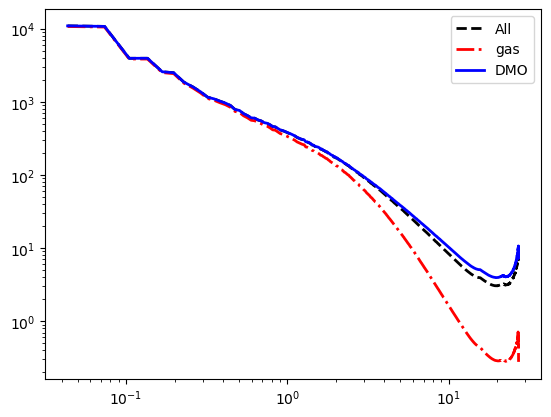

In [25]:
plt.figure()
plt.plot(Pk_all_hydro.k3D, Pk_all_hydro.Pk[:,0], 'k--', lw=2, label='All')
plt.plot(Pk_gas_hydro.k3D, Pk_gas_hydro.Pk[:,0], 'r-.', lw=2, label='gas')
plt.plot(Pk_DMO.k3D, Pk_DMO.Pk[:,0], 'b-', lw=2, label='DMO')

plt.xscale('log')
plt.yscale('log')
plt.legend()





Text(0.5, 1.0, 'TNG300-LRES')

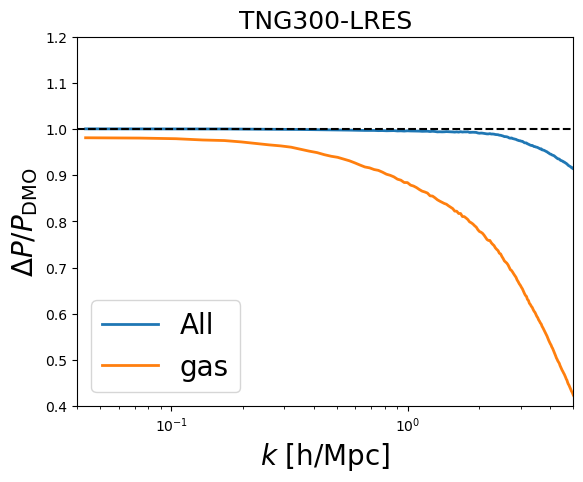

In [47]:
plt.figure()
plt.plot(Pk_all_hydro.k3D, Pk_all_hydro.Pk[:,0]/Pk_DMO.Pk[:,0],  lw=2, label='All')
plt.plot(Pk_gas_hydro.k3D, Pk_gas_hydro.Pk[:,0]/Pk_DMO.Pk[:,0], lw=2, label='gas')
# plt.plot(Pk_DMO.k3D, Pk_DMO.Pk[:,0], 'b-', lw=2, label='DMO')
plt.ylim(0.4, 1.2)
plt.ylabel(r'$\Delta P/P_{\rm DMO}$', fontsize=20)
plt.xlabel(r'$k$ [h/Mpc]', fontsize=20)
plt.axhline(1.0, color='k', linestyle='--')

plt.xlim(0.04, 5)
plt.xscale('log')
# plt.yscale('log')
plt.legend(fontsize=20)
plt.title('TNG300-LRES', fontsize=18)




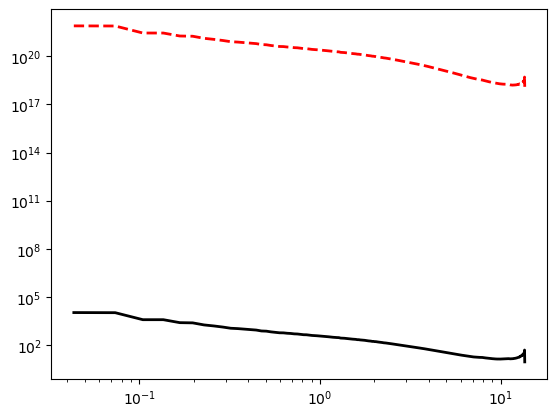

In [11]:
plt.figure()
plt.plot(Pk_all.k3D, Pk_all.Pk[:,0], 'k-', lw=2, label='All')
plt.plot(Pk_gas_no_norm.k3D, Pk_gas_no_norm.Pk[:,0], 'r--', lw=2, label='gas')
plt.xscale('log')
plt.yscale('log')




In [ ]:

fout = ldir + 'Pk_all_nb_' + str(grid) + '_Ilpy.txt'
np.savetxt(fout, np.transpose([Pk.k3D, Pk.Pk[:,0]]), delimiter='\t')